# Do Height and Weight Predict Grip Strength?

**Question.** Grip strength is a common proxy for overall physical frailty. If it tracks
closely with something as easy to measure as height or weight, those cheaper measurements
could stand in for it. This notebook tests whether they do.

**Data.** 10 observations of height, weight, age, grip strength, and a frailty flag.

**Headline result.** Neither height nor weight shows a usable relationship with grip
strength here — but with *n* = 10 the honest conclusion is "this sample can't tell us,"
not "no relationship exists." The confidence intervals below make that explicit.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.precision", 3)
RAW = "../data/raw/raw_yield_data.csv"
PROCESSED = "../data/processed/"

## 1. Load the raw data

In [2]:
df = pd.read_csv(RAW)
print(f"{df.shape[0]} rows x {df.shape[1]} columns")
df

10 rows x 5 columns


,Height (Inches),Weight (pounds),Age,Grip Strength,Frailty
0,65.8,112,30,30,N
1,71.5,136,19,31,N
2,69.4,153,45,29,N
3,68.2,142,22,28,Y
4,67.8,144,29,24,Y
5,68.7,123,50,26,N
6,69.8,141,51,22,Y
7,70.1,136,23,20,Y
8,67.9,112,17,19,N
9,66.8,120,39,31,N


## 2. Clean

One categorical column, `Frailty`, holds Y/N. Mapping it to 1/0 makes it usable in a
correlation matrix. This is label encoding, not one-hot — with a single binary column the
two are equivalent, so the extra column one-hot would produce is redundant.

In [3]:
df["Frailty"] = df["Frailty"].map({"N": 0, "Y": 1}).astype(int)

assert df["Frailty"].isin([0, 1]).all(), "unmapped Frailty values"
assert not df.isna().any().any(), "unexpected missing values"

df.to_csv(PROCESSED + "cleaned_yield_data.csv", index=False)
df.head()

,Height (Inches),Weight (pounds),Age,Grip Strength,Frailty
0,65.8,112,30,30,0
1,71.5,136,19,31,0
2,69.4,153,45,29,0
3,68.2,142,22,28,1
4,67.8,144,29,24,1


## 3. How does each measurement relate to grip strength?

In [4]:
predictors = ["Height (Inches)", "Weight (pounds)", "Age"]

rows = []
for col in predictors:
    r, p = stats.pearsonr(df[col], df["Grip Strength"])
    # Fisher z-transform for the 95% CI on r
    z = np.arctanh(r)
    se = 1 / np.sqrt(len(df) - 3)
    lo, hi = np.tanh([z - 1.96 * se, z + 1.96 * se])
    rows.append({"predictor": col, "r": r, "p-value": p,
                 "95% CI low": lo, "95% CI high": hi})

corr = pd.DataFrame(rows).set_index("predictor")
corr

,r,p-value,95% CI low,95% CI high
predictor,,,,
Height (Inches),-0.168,0.643,-0.721,0.516
Weight (pounds),0.033,0.928,-0.609,0.649
Age,0.134,0.713,-0.541,0.704


### Reading this table

Every confidence interval spans zero and runs from strongly negative to strongly positive.
With 10 observations the interval is roughly ±0.65 wide no matter what — the data is
consistent with a strong positive relationship, a strong negative one, or none at all.

That is the real finding: **the sample is too small to detect anything.** Reporting
"height and weight don't correlate with grip strength" would overstate what 10 rows
support.

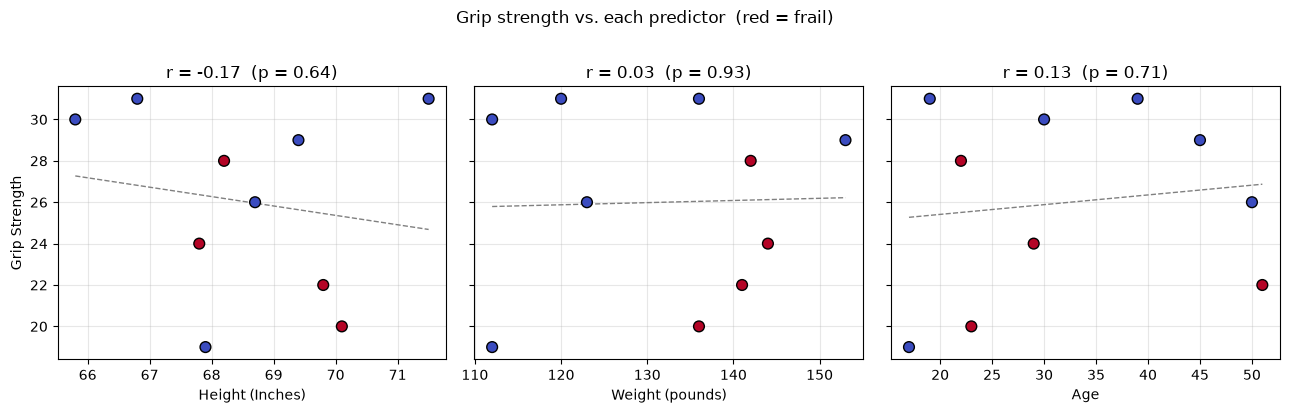

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, col in zip(axes, predictors):
    ax.scatter(df[col], df["Grip Strength"], s=60,
               c=df["Frailty"], cmap="coolwarm", edgecolor="black", zorder=3)
    # least-squares fit line for visual reference only
    m, b = np.polyfit(df[col], df["Grip Strength"], 1)
    xs = np.linspace(df[col].min(), df[col].max(), 50)
    ax.plot(xs, m * xs + b, "--", color="grey", linewidth=1)
    ax.set_xlabel(col)
    ax.set_title(f"r = {corr.loc[col, 'r']:.2f}  (p = {corr.loc[col, 'p-value']:.2f})")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Grip Strength")
fig.suptitle("Grip strength vs. each predictor  (red = frail)", y=1.02)
fig.tight_layout()
fig.savefig("../results/grip_strength_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Drop the uninformative columns

Height and weight carry no signal we can act on, so the reduced table keeps age, grip
strength, and frailty. Keeping the dropped columns in `cleaned_yield_data.csv` means
nothing is lost if a larger sample arrives later.

In [6]:
reduced = df.drop(columns=["Height (Inches)", "Weight (pounds)"])
reduced.to_csv(PROCESSED + "cleaned_data.csv", index=False)
reduced

,Age,Grip Strength,Frailty
0,30,30,0
1,19,31,0
2,45,29,0
3,22,28,1
4,29,24,1
5,50,26,0
6,51,22,1
7,23,20,1
8,17,19,0
9,39,31,0


## Findings

| Predictor | r | 95% CI | Verdict |
|---|---|---|---|
| Height (inches) | -0.17 | [-0.72, 0.52] | Inconclusive — CI spans zero |
| Weight (pounds) | 0.03 | [-0.61, 0.65] | Inconclusive — CI spans zero |
| Age | 0.13 | [-0.54, 0.70] | Inconclusive — CI spans zero |

1. No predictor reaches significance, and all three intervals comfortably contain zero.
2. The limiting factor is sample size, not effect size. To detect a moderate correlation
   (*r* = 0.5) at 80% power you need roughly 29 observations; this dataset has 10.
3. **Next step:** collect more observations before drawing any conclusion about which
   measurements predict grip strength.

### Outputs
- `data/processed/cleaned_yield_data.csv` — encoded, all columns retained
- `data/processed/cleaned_data.csv` — reduced feature set
- `results/grip_strength_scatter.png`